<a href="https://colab.research.google.com/github/abhi-shek16/assistflow-ai-triage/blob/main/AssistFlow_AI_Triage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🤖 AssistFlow AI — Intelligent Ticket Triage System
### Powered by Groq API + LLaMA 3 | Built for FlowBridge Technologies

---

## 📌 Project Overview

**Problem:** FlowBridge Technologies receives **7,000+ support tickets/day**. Their keyword-based triage system misroutes tickets, wastes agent time, and costs **$800,000/year** in inefficiency.

**Solution:** AssistFlow AI — an LLM-powered triage pipeline that understands ticket *intent*, not just keywords.

| Feature | Description |
|---|---|
| 🎯 Issue Classification | Categorizes tickets into 9 issue types |
| 🚨 Urgency Scoring | CRITICAL / HIGH / MEDIUM / LOW |
| 💡 Action Suggestion | Tells agents exactly what to do next |
| 🔍 Explainability | Reasoning behind every classification |
| 🔬 A/B Prompt Testing | Compares two prompts to find the best one |
| 🚨 Drift Detection | Alerts when ticket patterns suddenly change |
| ⚡ Model Benchmarking | Speed vs accuracy across LLaMA models |

**Tech Stack:** `Python` · `Groq API` · `LLaMA-3.3-70B` · `Pandas` · `Matplotlib`


## ⚙️ Step 1: Install Dependencies

In [1]:
!pip install groq pandas matplotlib seaborn -q
print("✅ All libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.0 MB/s eta 0:00:00
✅ All libraries installed successfully!


## ⚙️ Step 2: Imports & API Configuration

> 💡 **How to add your Groq API key securely:**  
> Click the 🔑 **Secrets** icon in the left sidebar → Add secret → Name: `GROQ_API_KEY` → Paste your key


In [2]:
import os, json, time, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from groq import Groq
from IPython.display import display, HTML
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# ── API Key Setup ──────────────────────────────────────────────────────────────
try:
    from google.colab import userdata
    GROQ_API_KEY = userdata.get('GROQ_API_KEY')
    print("✅ API key loaded from Colab Secrets (secure)")
except Exception:
    GROQ_API_KEY = "your-groq-api-key-here"   # ← fallback: paste your key here
    print("⚠️  Using hardcoded key — use Colab Secrets for production")

client = Groq(api_key=GROQ_API_KEY)

# ── Model Configuration ────────────────────────────────────────────────────────
MODEL_MAIN  = "llama-3.3-70b-versatile"   # Primary: high accuracy
MODEL_FAST  = "llama-3.1-8b-instant"      # Benchmark: high speed

print(f"\n🤖 Primary Model  : {MODEL_MAIN}")
print(f"⚡ Benchmark Model : {MODEL_FAST}")
print("\n🚀 AssistFlow AI is ready!")

✅ API key loaded from Colab Secrets (secure)

🤖 Primary Model  : llama-3.3-70b-versatile
⚡ Benchmark Model : llama-3.1-8b-instant

🚀 AssistFlow AI is ready!


---
## 📊 Step 3: Mock Ticket Dataset

20 realistic support tickets across 4 urgency levels, 3 channels, and 4 customer tiers.  
*(Tickets 19–20 simulate a new AI-feature trend — used later for drift detection)*


In [3]:
tickets = [

    # ═══════════════════════════════ CRITICAL ═══════════════════════════════════
    {
        "id": "TKT-001", "channel": "email", "customer_tier": "Enterprise",
        "message": (
            "URGENT: Our entire team of 200 employees has been locked out of the platform "
            "since 6 AM. Nothing works — login, dashboard, everything. We have SLA commitments "
            "to our own customers. If this is not resolved in 1 hour, we are escalating legally."
        )
    },
    {
        "id": "TKT-002", "channel": "email", "customer_tier": "Premium",
        "message": (
            "I believe our account has been compromised. We're seeing active sessions from "
            "Singapore and Russia — locations we've never accessed from. We handle sensitive "
            "financial data for 3 clients. Please suspend our account and help us investigate immediately."
        )
    },
    {
        "id": "TKT-003", "channel": "chat", "customer_tier": "Premium",
        "message": (
            "3 weeks of project data just disappeared after the update you pushed last night. "
            "I'm talking about critical client deliverables — gone. Our team is in panic mode. "
            "We need our data recovered NOW. This is a catastrophic data loss."
        )
    },
    {
        "id": "TKT-004", "channel": "web", "customer_tier": "Enterprise",
        "message": (
            "SSO authentication has completely broken after your v4.2 release. None of our "
            "500 users can log in. We have a board-level product demo in 90 minutes. "
            "This is blocking our entire company. Need immediate fix or rollback."
        )
    },

    # ═══════════════════════════════ HIGH ═══════════════════════════════════════
    {
        "id": "TKT-005", "channel": "email", "customer_tier": "Premium",
        "message": (
            "I was charged $2,400 on my invoice instead of $240. That's 10x the normal amount. "
            "I've compared invoices from the last 3 months and this month is clearly wrong. "
            "Please refund the extra $2,160 immediately and confirm what caused this."
        )
    },
    {
        "id": "TKT-006", "channel": "chat", "customer_tier": "Premium",
        "message": (
            "Our REST API integration is throwing 503 errors every 3-4 minutes. "
            "Error rate jumped from 0% to 43% in the last hour. Our production app depends "
            "on this endpoint. I've attached our error logs. Need urgent investigation."
        )
    },
    {
        "id": "TKT-007", "channel": "email", "customer_tier": "Standard",
        "message": (
            "Password reset is completely broken. I've clicked 'Forgot Password' 7 times "
            "over the past 2 hours. No email arrives — checked inbox, spam, promotions. "
            "I have a project deadline in 3 hours and all my work is locked in the account."
        )
    },
    {
        "id": "TKT-008", "channel": "web", "customer_tier": "Enterprise",
        "message": (
            "Our outgoing webhooks stopped firing 4 hours ago. We use these to sync real-time "
            "data to our internal ERP system. The data inconsistency is now affecting our "
            "operations team. Endpoint is returning 200 but events are not being dispatched."
        )
    },
    {
        "id": "TKT-009", "channel": "chat", "customer_tier": "Premium",
        "message": (
            "The iOS mobile app crashes every time I open the Reports tab. "
            "I've tried reinstalling twice — same result. Running iOS 17.4, iPhone 15. "
            "My entire team of 12 people uses reports daily. This is blocking our workflow."
        )
    },

    # ═══════════════════════════════ MEDIUM ══════════════════════════════════════
    {
        "id": "TKT-010", "channel": "email", "customer_tier": "Standard",
        "message": (
            "The PDF export feature is cutting off the last 2 columns in every table. "
            "I've tested with different reports — same bug every time. I need these exports "
            "for a client presentation on Friday. It's not urgent but I do need it fixed soon."
        )
    },
    {
        "id": "TKT-011", "channel": "web", "customer_tier": "Standard",
        "message": (
            "I want to cancel my subscription and get a prorated refund for the remaining "
            "8 months of my annual plan. The product has too many bugs and support response "
            "times have been disappointing. Please process this and confirm via email."
        )
    },
    {
        "id": "TKT-012", "channel": "chat", "customer_tier": "Premium",
        "message": (
            "Dashboard loading time has gone from ~2 seconds to 15-20 seconds over the "
            "past 3 days. My internet is fine — other sites load instantly. "
            "Not blocking my work completely but it's really hurting my productivity."
        )
    },
    {
        "id": "TKT-013", "channel": "email", "customer_tier": "Standard",
        "message": (
            "Report generation keeps failing with error code ERR_GEN_402. "
            "Tried 4 times across different report types — same error. "
            "I need this for an internal review on Friday. Not super urgent but needs fixing."
        )
    },
    {
        "id": "TKT-014", "channel": "web", "customer_tier": "Free",
        "message": (
            "I'd like to permanently delete my account and all my personal data in compliance "
            "with GDPR. Can you either walk me through the process or do it for me? "
            "Please send a confirmation once deletion is complete."
        )
    },

    # ═══════════════════════════════ LOW ═════════════════════════════════════════
    {
        "id": "TKT-015", "channel": "chat", "customer_tier": "Free",
        "message": (
            "Hey! Quick question — is there a list of keyboard shortcuts for the dashboard? "
            "I feel like I'm clicking around too much. Would love to speed up my workflow!"
        )
    },
    {
        "id": "TKT-016", "channel": "email", "customer_tier": "Standard",
        "message": (
            "I'm considering upgrading from Standard to Premium. Could you tell me what "
            "additional features I'd get access to? Also, is there a discount for switching "
            "to annual billing? No rush on this — just exploring my options."
        )
    },
    {
        "id": "TKT-017", "channel": "web", "customer_tier": "Free",
        "message": (
            "Email notifications from the platform are arriving about 25-30 minutes late. "
            "For example, I get a 'task assigned' notification half an hour after the task was created. "
            "It's a bit annoying but not blocking anything critical for me."
        )
    },
    {
        "id": "TKT-018", "channel": "chat", "customer_tier": "Standard",
        "message": (
            "Just a suggestion — it would be amazing if FlowBridge added a dark mode! "
            "The bright white interface is really hard on the eyes during long work sessions. "
            "A lot of my colleagues have been asking about this too."
        )
    },

    # ═══════════════════════════ DRIFT TICKETS ════════════════════════════════════
    # These simulate a sudden spike in AI/automation-related requests
    # The drift detection system should flag this as an emerging trend
    {
        "id": "TKT-019", "channel": "email", "customer_tier": "Enterprise",
        "message": (
            "We want to understand FlowBridge's AI roadmap. Can your platform integrate "
            "with our internal LLM deployment? We're looking to build AI agents that "
            "automate our entire workflow management. Do you support LangChain or similar?"
        )
    },
    {
        "id": "TKT-020", "channel": "web", "customer_tier": "Premium",
        "message": (
            "Does FlowBridge support AI-powered automation rules? We want to automatically "
            "route and categorize tasks based on content semantics — not just manual tags. "
            "Competitors are offering ChatGPT integration. Is this on your roadmap?"
        )
    },
]

print(f"✅ Dataset loaded: {len(tickets)} support tickets\n")
channel_counts = Counter(t['channel'] for t in tickets)
tier_counts    = Counter(t['customer_tier'] for t in tickets)
print(f"  📡 Channels : {dict(channel_counts)}")
print(f"  👥 Tiers    : {dict(tier_counts)}")

✅ Dataset loaded: 20 support tickets

  📡 Channels : {'email': 8, 'chat': 6, 'web': 6}
  👥 Tiers    : {'Enterprise': 4, 'Premium': 7, 'Standard': 6, 'Free': 3}


---
## 🤖 Step 4: Core AI Triage Pipeline

### Prompt Engineering

The system prompt is the most critical part. It defines how the AI thinks about each ticket.


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  SYSTEM PROMPT V1 — Detailed, Rule-Based
# ══════════════════════════════════════════════════════════════════════════════
SYSTEM_PROMPT_V1 = """You are AssistFlow AI, an expert support triage assistant for FlowBridge Technologies — a B2B SaaS platform with 300+ global agents.

YOUR JOB: Analyze each support ticket and return a structured JSON response. Your output directly guides agents, so be accurate and specific.

━━━ URGENCY RULES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
CRITICAL  → Full service outage, data loss, security breach, enterprise customer blocked
HIGH      → Core feature broken, billing error, API failure, customer has a deadline
MEDIUM    → Non-blocking bug, performance degradation, refund/cancellation request
LOW       → Feature request, general question, UI preference, upgrade inquiry

━━━ ISSUE CATEGORIES ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
access_authentication | billing_payments | data_integrity | api_integration
performance | feature_request | account_management | security | general_inquiry

━━━ ESCALATION GUIDE ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
security → Security Team
data_integrity + CRITICAL → Data Recovery Team
api_integration + Enterprise → Platform Engineering
billing → Billing Department
null → No escalation needed

━━━ OUTPUT FORMAT ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Respond ONLY with valid JSON. No preamble. No markdown. Just the JSON object.

{
  "issue_category"      : "<category from list above>",
  "urgency"             : "CRITICAL | HIGH | MEDIUM | LOW",
  "confidence"          : <float 0.0–1.0>,
  "real_issue"          : "<one clear sentence: what is actually broken/needed>",
  "customer_sentiment"  : "frustrated | angry | neutral | satisfied",
  "suggested_action"    : "<specific, actionable next step for the support agent>",
  "escalate_to"         : "<team name or null>",
  "reasoning"           : "<2–3 sentences explaining your urgency and category choice>"
}"""

print("✅ System Prompt V1 defined")
print(f"   Length: {len(SYSTEM_PROMPT_V1)} characters")

✅ System Prompt V1 defined
   Length: 1831 characters


In [5]:
def triage_ticket(ticket: dict,
                  model: str       = MODEL_MAIN,
                  system_prompt: str = SYSTEM_PROMPT_V1) -> dict:
    """
    Analyzes a support ticket using an LLM and returns structured triage output.

    Args:
        ticket        : dict with keys — id, channel, customer_tier, message
        model         : Groq model string
        system_prompt : The system prompt to use

    Returns:
        dict — triage result merged with ticket metadata
    """
    user_content = (
        f"Ticket ID    : {ticket['id']}\n"
        f"Channel      : {ticket['channel']}\n"
        f"Customer Tier: {ticket['customer_tier']}\n"
        f"Message      : {ticket['message']}"
    )

    start = time.time()

    try:
        response = client.chat.completions.create(
            model    = model,
            messages = [
                {"role": "system", "content": system_prompt},
                {"role": "user",   "content": user_content},
            ],
            temperature = 0.1,     # Low temperature → consistent, structured output
            max_tokens  = 450,
        )

        latency    = round(time.time() - start, 2)
        raw_output = response.choices[0].message.content.strip()

        # Strip markdown fences if model adds them
        if "```" in raw_output:
            raw_output = raw_output.split("```")[1]
            if raw_output.startswith("json"):
                raw_output = raw_output[4:].strip()

        result = json.loads(raw_output)
        result.update({
            "ticket_id" : ticket["id"],
            "channel"   : ticket["channel"],
            "tier"      : ticket["customer_tier"],
            "latency_s" : latency,
            "model"     : model,
            "status"    : "success",
        })

    except json.JSONDecodeError as e:
        result = {
            "ticket_id": ticket["id"], "status": "parse_error",
            "error": str(e),
            "latency_s": round(time.time() - start, 2), "model": model,
        }
    except Exception as e:
        result = {
            "ticket_id": ticket["id"], "status": "api_error",
            "error": str(e),
            "latency_s": round(time.time() - start, 2), "model": model,
        }

    return result


print("✅ triage_ticket() pipeline function defined!")

✅ triage_ticket() pipeline function defined!


### 🧪 Quick Test — Single Ticket (TKT-001)

In [6]:
sample = triage_ticket(tickets[0])

EMOJI = {"CRITICAL": "🔴", "HIGH": "🟠", "MEDIUM": "🟡", "LOW": "🟢"}
urg   = sample.get("urgency", "N/A")

print(f"🎫 Ticket  : {sample['ticket_id']}  ({sample['tier']})")
print(f"⏱️  Latency : {sample['latency_s']}s")
print(f"\n{EMOJI.get(urg,'⚪')} Urgency   : {urg}")
print(f"📂 Category : {sample.get('issue_category','N/A')}")
print(f"😤 Sentiment: {sample.get('customer_sentiment','N/A')}")
print(f"🎯 Conf.    : {sample.get('confidence', 0):.0%}")
print(f"\n🔍 Real Issue     : {sample.get('real_issue','N/A')}")
print(f"💡 Action         : {sample.get('suggested_action','N/A')}")
print(f"🚨 Escalate To    : {sample.get('escalate_to','null')}")
print(f"\n🧠 Reasoning: {sample.get('reasoning','N/A')}")

🎫 Ticket  : TKT-001  (Enterprise)
⏱️  Latency : 0.92s

🔴 Urgency   : CRITICAL
📂 Category : access_authentication
😤 Sentiment: angry
🎯 Conf.    : 99%

🔍 Real Issue     : The entire team of 200 employees is locked out of the platform and unable to access any features
💡 Action         : Immediately investigate the cause of the lockout and work to restore access to the platform for the entire team
🚨 Escalate To    : Security Team

🧠 Reasoning: The customer is experiencing a full service outage, which is classified as a critical issue due to the impact on their business operations and SLA commitments. The urgency is high due to the short timeframe for resolution and the threat of legal escalation. The issue category is access_authentication because the customer's team is unable to log in to the platform.


---
## 🔄 Step 5: Batch Processing — All 20 Tickets


In [7]:
results = []
failed  = []

URGENCY_EMOJI = {"CRITICAL": "🔴", "HIGH": "🟠", "MEDIUM": "🟡", "LOW": "🟢"}

print(f"{'─'*70}")
print(f"  Processing {len(tickets)} tickets with {MODEL_MAIN}")
print(f"{'─'*70}")

for i, ticket in enumerate(tickets, 1):
    result = triage_ticket(ticket)
    results.append(result)

    if result["status"] == "success":
        urg  = result.get("urgency", "N/A")
        cat  = result.get("issue_category", "N/A")
        conf = result.get("confidence", 0)
        e    = URGENCY_EMOJI.get(urg, "⚪")
        print(f"  [{i:02d}/20] {ticket['id']}  {e} {urg:<10}  📂 {cat:<28}  "
              f"🎯 {conf:.0%}  ⏱️ {result['latency_s']}s")
    else:
        failed.append(ticket['id'])
        print(f"  [{i:02d}/20] {ticket['id']}  ❌ {result['status']} — {result.get('error','')[:50]}")

    time.sleep(0.4)   # Respect rate limits

print(f"{'─'*70}")
print(f"\n  ✅ Success : {len(results)-len(failed)}/{len(tickets)} tickets")
if failed:
    print(f"  ❌ Failed  : {failed}")

──────────────────────────────────────────────────────────────────────
  Processing 20 tickets with llama-3.3-70b-versatile
──────────────────────────────────────────────────────────────────────
  [01/20] TKT-001  🔴 CRITICAL    📂 access_authentication         🎯 99%  ⏱️ 1.09s
  [02/20] TKT-002  🔴 CRITICAL    📂 security                      🎯 95%  ⏱️ 0.71s
  [03/20] TKT-003  🔴 CRITICAL    📂 data_integrity                🎯 99%  ⏱️ 0.7s
  [04/20] TKT-004  🔴 CRITICAL    📂 access_authentication         🎯 99%  ⏱️ 0.61s
  [05/20] TKT-005  🟠 HIGH        📂 billing_payments              🎯 90%  ⏱️ 0.76s
  [06/20] TKT-006  🔴 CRITICAL    📂 api_integration               🎯 95%  ⏱️ 0.71s
  [07/20] TKT-007  🟠 HIGH        📂 access_authentication         🎯 90%  ⏱️ 1.02s
  [08/20] TKT-008  🟠 HIGH        📂 api_integration               🎯 90%  ⏱️ 1.06s
  [09/20] TKT-009  🟠 HIGH        📂 performance                   🎯 90%  ⏱️ 0.68s
  [10/20] TKT-010  🟠 HIGH        📂 feature_request               🎯 90%  ⏱️ 1.

### 📋 Results Table

In [8]:
success_results = [r for r in results if r.get("status") == "success"]

df = pd.DataFrame([{
    "Ticket"     : r["ticket_id"],
    "Tier"       : r["tier"],
    "Urgency"    : r.get("urgency", "N/A"),
    "Category"   : r.get("issue_category", "N/A"),
    "Confidence" : r.get("confidence", 0),
    "Sentiment"  : r.get("customer_sentiment", "N/A"),
    "Escalate"   : r.get("escalate_to", "null"),
    "Latency(s)" : r["latency_s"],
} for r in success_results])

# Style urgency column
def style_urgency(val):
    palette = {
        "CRITICAL": "background-color:#c0392b;color:white;font-weight:bold",
        "HIGH"    : "background-color:#e67e22;color:white;font-weight:bold",
        "MEDIUM"  : "background-color:#f1c40f;color:#333;font-weight:bold",
        "LOW"     : "background-color:#27ae60;color:white;font-weight:bold",
    }
    return palette.get(val, "")

display(
    df.style
      .applymap(style_urgency, subset=["Urgency"])
      .format({"Confidence": "{:.0%}", "Latency(s)": "{:.2f}s"})
      .set_properties(**{"text-align": "left"})
      .set_caption("AssistFlow AI — Triage Results")
)
print(f"\nTotal: {len(df)} tickets processed")

,Ticket,Tier,Urgency,Category,Confidence,Sentiment,Escalate,Latency(s)
0,TKT-001,Enterprise,CRITICAL,access_authentication,99%,angry,Security Team,1.09s
1,TKT-002,Premium,CRITICAL,security,95%,frustrated,Security Team,0.71s
2,TKT-003,Premium,CRITICAL,data_integrity,99%,frustrated,Data Recovery Team,0.70s
3,TKT-004,Enterprise,CRITICAL,access_authentication,99%,frustrated,Security Team,0.61s
4,TKT-005,Premium,HIGH,billing_payments,90%,frustrated,Billing Department,0.76s
5,TKT-006,Premium,CRITICAL,api_integration,95%,frustrated,Platform Engineering,0.71s
6,TKT-007,Standard,HIGH,access_authentication,90%,frustrated,null,1.02s
7,TKT-008,Enterprise,HIGH,api_integration,90%,frustrated,Platform Engineering,1.06s
8,TKT-009,Premium,HIGH,performance,90%,frustrated,Platform Engineering,0.68s
9,TKT-010,Standard,HIGH,feature_request,90%,neutral,null,1.05s



Total: 20 tickets processed


---
## 📈 Step 6: Analytics Dashboard


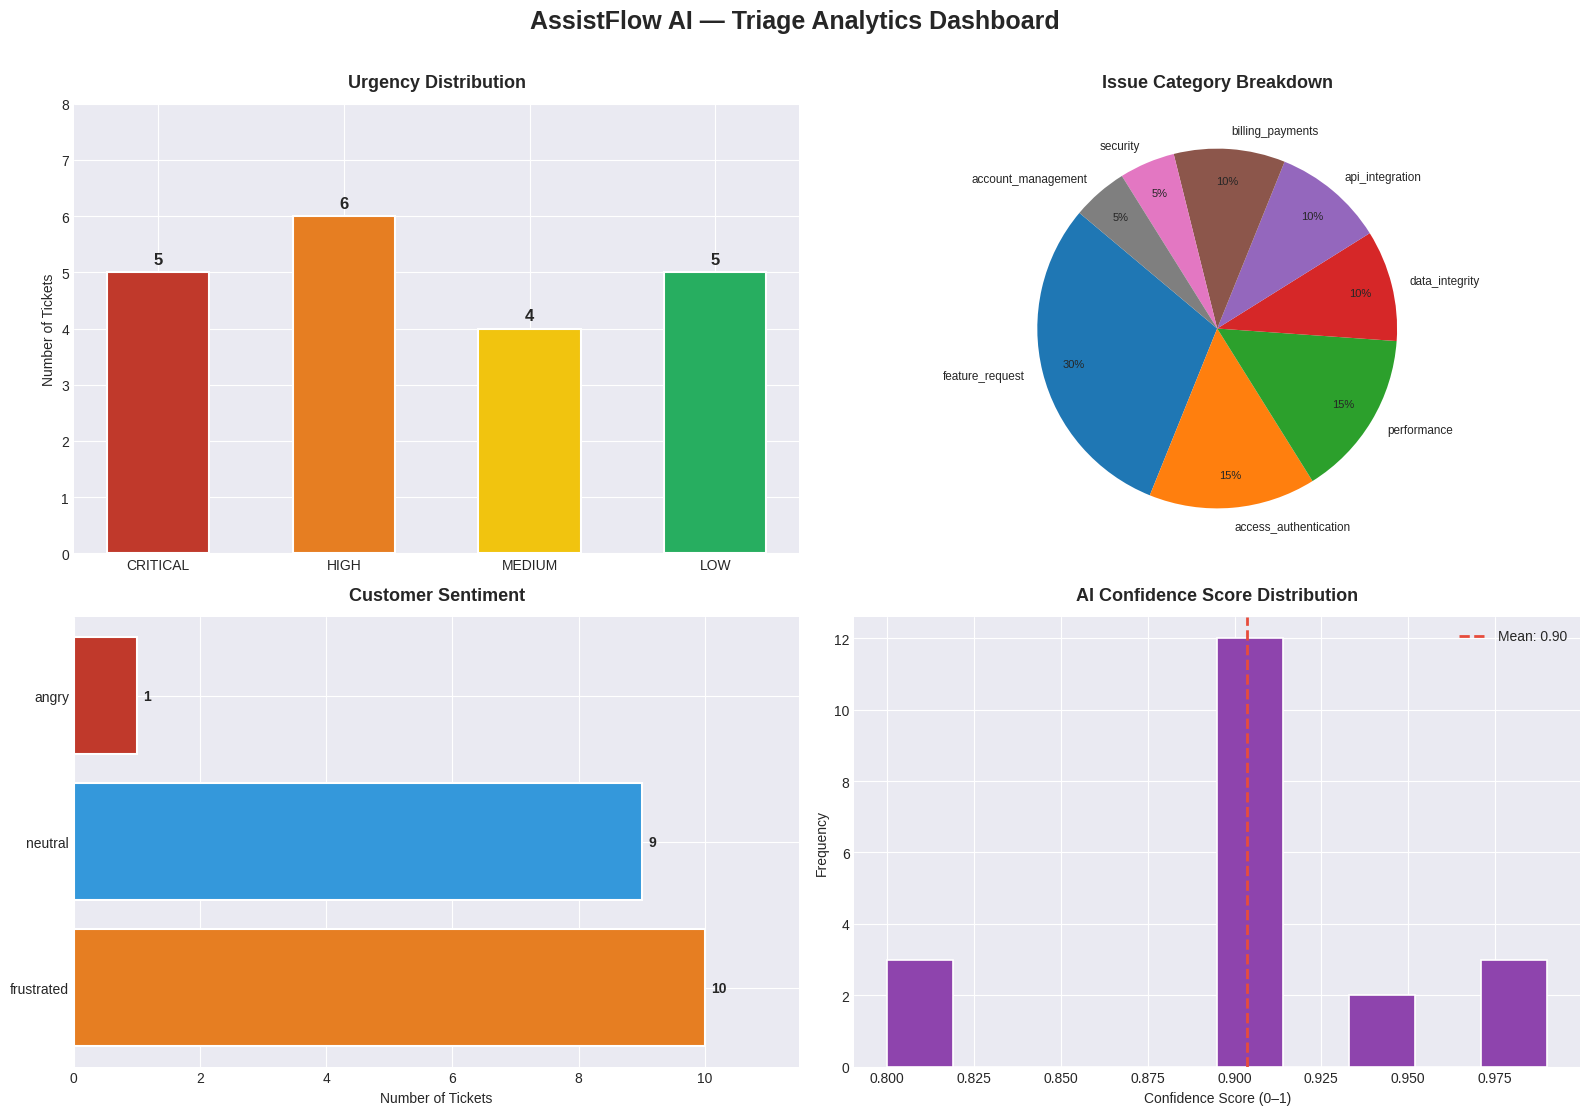


📊 Key Metrics:
  • Avg Confidence  : 90.35%
  • Avg Latency     : 0.84s per ticket
  • Critical Tickets: 5
  • Escalations     : 9 tickets


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("AssistFlow AI — Triage Analytics Dashboard", fontsize=18, fontweight="bold", y=1.01)

URGENCY_ORDER  = ["CRITICAL", "HIGH", "MEDIUM", "LOW"]
URGENCY_COLORS = ["#c0392b", "#e67e22", "#f1c40f", "#27ae60"]

# ── Plot 1: Urgency Distribution ───────────────────────────────────────────────
ax = axes[0, 0]
urg_counts = df["Urgency"].value_counts().reindex(
    [u for u in URGENCY_ORDER if u in df["Urgency"].values]
)
bars = ax.bar(urg_counts.index, urg_counts.values,
              color=URGENCY_COLORS[:len(urg_counts)], edgecolor="white", linewidth=1.5, width=0.55)
ax.set_title("Urgency Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Number of Tickets")
ax.set_ylim(0, max(urg_counts.values) + 2)
for bar, val in zip(bars, urg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            str(val), ha="center", fontsize=12, fontweight="bold")

# ── Plot 2: Category Pie Chart ────────────────────────────────────────────────
ax = axes[0, 1]
cat_counts = df["Category"].value_counts()
wedges, texts, autotexts = ax.pie(
    cat_counts.values, labels=cat_counts.index,
    autopct="%1.0f%%", startangle=140,
    pctdistance=0.82, textprops={"fontsize": 8.5}
)
for at in autotexts: at.set_fontsize(8)
ax.set_title("Issue Category Breakdown", fontsize=13, fontweight="bold", pad=12)

# ── Plot 3: Sentiment Analysis ────────────────────────────────────────────────
ax = axes[1, 0]
sent_palette = {
    "angry"     : "#c0392b",
    "frustrated": "#e67e22",
    "neutral"   : "#3498db",
    "satisfied" : "#27ae60",
}
sent_counts = df["Sentiment"].value_counts()
colors_sent = [sent_palette.get(s, "#95a5a6") for s in sent_counts.index]
hbars = ax.barh(sent_counts.index, sent_counts.values,
                color=colors_sent, edgecolor="white", linewidth=1.5)
ax.set_title("Customer Sentiment", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Tickets")
ax.set_xlim(0, max(sent_counts.values) + 1.5)
for i, val in enumerate(sent_counts.values):
    ax.text(val + 0.1, i, str(val), va="center", fontweight="bold")

# ── Plot 4: Confidence Score Distribution ─────────────────────────────────────
ax = axes[1, 1]
ax.hist(df["Confidence"], bins=10, color="#8e44ad", edgecolor="white", linewidth=1.2)
mean_conf = df["Confidence"].mean()
ax.axvline(mean_conf, color="#e74c3c", linestyle="--", linewidth=2,
           label=f"Mean: {mean_conf:.2f}")
ax.set_title("AI Confidence Score Distribution", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Confidence Score (0–1)")
ax.set_ylabel("Frequency")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig("analytics_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📊 Key Metrics:")
print(f"  • Avg Confidence  : {df['Confidence'].mean():.2%}")
print(f"  • Avg Latency     : {df['Latency(s)'].mean():.2f}s per ticket")
print(f"  • Critical Tickets: {(df['Urgency']=='CRITICAL').sum()}")
print(f"  • Escalations     : {(df['Escalate'] != 'null').sum()} tickets")

---
## 🔬 Step 7: A/B Prompt Testing

Testing two system prompts on the same tickets to find which produces higher confidence and accuracy.

| | Description |
|---|---|
| **Prompt A** | Minimal — short, direct, no rules |
| **Prompt B** | Detailed — urgency rules + escalation guide (V1) |


In [10]:
# ── Prompt A: Minimal ────────────────────────────────────────────────────────
SYSTEM_PROMPT_A = """You are a customer support classifier. Analyze the ticket and return ONLY this JSON:
{
  "issue_category"    : "<category>",
  "urgency"           : "CRITICAL | HIGH | MEDIUM | LOW",
  "confidence"        : <0.0-1.0>,
  "real_issue"        : "<one sentence>",
  "customer_sentiment": "frustrated | neutral | satisfied | angry",
  "suggested_action"  : "<next step>",
  "escalate_to"       : "<team or null>",
  "reasoning"         : "<short explanation>"
}"""

# Prompt B is our SYSTEM_PROMPT_V1 (detailed) — already defined above
SYSTEM_PROMPT_B = SYSTEM_PROMPT_V1

ab_tickets = tickets[:6]   # Run on first 6 tickets for cost efficiency
ab_results = {"A": [], "B": []}

print("Running A/B Test on 6 tickets...\n")

for ticket in ab_tickets:
    ra = triage_ticket(ticket, model=MODEL_MAIN, system_prompt=SYSTEM_PROMPT_A)
    rb = triage_ticket(ticket, model=MODEL_MAIN, system_prompt=SYSTEM_PROMPT_B)
    ab_results["A"].append(ra)
    ab_results["B"].append(rb)
    time.sleep(0.5)
    print(f"  ✅ {ticket['id']} processed")

# ── Results Comparison ────────────────────────────────────────────────────────
print("\n" + "═"*75)
print(f"  {'Ticket':<10} {'Urgency A':<13} {'Urgency B':<13} {'Conf A':>7} {'Conf B':>7}  Match?")
print("═"*75)

matches = 0
for ra, rb in zip(ab_results["A"], ab_results["B"]):
    ua, ub  = ra.get("urgency","ERR"), rb.get("urgency","ERR")
    ca, cb  = ra.get("confidence",0),  rb.get("confidence",0)
    matched = ua == ub
    if matched: matches += 1
    print(f"  {ra['ticket_id']:<10} {ua:<13} {ub:<13} {ca:>7.2f} {cb:>7.2f}  "
          f"{'✅' if matched else '❌'}")

print("═"*75)

avg_a = sum(r.get("confidence",0) for r in ab_results["A"] if r.get("status")=="success") / len(ab_tickets)
avg_b = sum(r.get("confidence",0) for r in ab_results["B"] if r.get("status")=="success") / len(ab_tickets)

print(f"\n  Agreement Rate    : {matches/len(ab_tickets):.0%}")
print(f"  Avg Confidence A  : {avg_a:.2f}")
print(f"  Avg Confidence B  : {avg_b:.2f}")
print(f"  🏆 Winner         : Prompt {'B (Detailed)' if avg_b >= avg_a else 'A (Minimal)'}")

Running A/B Test on 6 tickets...

  ✅ TKT-001 processed
  ✅ TKT-002 processed
  ✅ TKT-003 processed
  ✅ TKT-004 processed
  ✅ TKT-005 processed
  ✅ TKT-006 processed

═══════════════════════════════════════════════════════════════════════════
  Ticket     Urgency A     Urgency B      Conf A  Conf B  Match?
═══════════════════════════════════════════════════════════════════════════
  TKT-001    CRITICAL      CRITICAL         0.99    0.99  ✅
  TKT-002    CRITICAL      CRITICAL         0.90    0.95  ✅
  TKT-003    CRITICAL      CRITICAL         0.90    0.99  ✅
  TKT-004    CRITICAL      CRITICAL         0.90    0.99  ✅
  TKT-005    HIGH          HIGH             0.90    0.90  ✅
  TKT-006    CRITICAL      CRITICAL         0.90    0.95  ✅
═══════════════════════════════════════════════════════════════════════════

  Agreement Rate    : 100%
  Avg Confidence A  : 0.92
  Avg Confidence B  : 0.96
  🏆 Winner         : Prompt B (Detailed)


---
## 🚨 Step 8: Ticket Drift Detection

Monitors whether the pattern of incoming tickets is changing.  
If a new category suddenly spikes, it means a new bug, product issue, or customer trend is emerging.

**Algorithm:** Compare the last N tickets (sliding window) against the baseline distribution.


In [11]:
def detect_drift(results: list, window_size: int = 5, threshold: float = 0.35) -> dict:
    """
    Detects category drift by comparing the recent ticket window
    against the overall baseline distribution.

    Args:
        results     : list of triage result dicts
        window_size : number of recent tickets to treat as 'recent'
        threshold   : min proportion increase to trigger an alert

    Returns:
        dict with status, alerts, and per-category delta breakdown
    """
    success = [r for r in results if r.get("status") == "success"]

    if len(success) < window_size + 1:
        return {"status": "insufficient_data", "alerts": []}

    baseline_cats = [r.get("issue_category","unknown") for r in success[:-window_size]]
    recent_cats   = [r.get("issue_category","unknown") for r in success[-window_size:]]

    baseline_dist = Counter(baseline_cats)
    recent_dist   = Counter(recent_cats)
    n_base, n_rec = len(baseline_cats), len(recent_cats)

    alerts  = []
    deltas  = {}
    all_cats = set(list(baseline_dist) + list(recent_dist))

    for cat in all_cats:
        bp = baseline_dist.get(cat, 0) / n_base
        rp = recent_dist.get(cat, 0)   / n_rec
        d  = rp - bp
        deltas[cat] = {"baseline": bp, "recent": rp, "delta": d}
        if d > threshold:
            alerts.append({
                "category"   : cat,
                "baseline"   : f"{bp:.0%}",
                "recent"     : f"{rp:.0%}",
                "delta"      : f"+{d:.0%}",
                "severity"   : "HIGH" if d > 0.5 else "MEDIUM",
            })

    return {
        "status"  : "drift_detected" if alerts else "stable",
        "window"  : window_size,
        "analyzed": len(success),
        "alerts"  : alerts,
        "deltas"  : deltas,
    }


# ── Run Detection ─────────────────────────────────────────────────────────────
drift = detect_drift(results, window_size=5, threshold=0.35)

print("╔══════════════════════════════════════════════════════╗")
print("║        🚨 ASSISTFLOW DRIFT DETECTION REPORT          ║")
print("╚══════════════════════════════════════════════════════╝")
print(f"  Status           : {drift['status'].upper()}")
print(f"  Tickets Analyzed : {drift['analyzed']}")
print(f"  Window Size      : Last {drift['window']} tickets vs baseline\n")

if drift["alerts"]:
    print("  ⚠️  ALERTS TRIGGERED:")
    for a in drift["alerts"]:
        print(f"     [{a['severity']}] '{a['category']}'")
        print(f"             Baseline: {a['baseline']}  →  Recent: {a['recent']}  (Δ {a['delta']})")
    print()
    print("  💡 Recommendation: Route these tickets to product team for trend analysis.")
else:
    print("  ✅ No significant drift. Ticket patterns are stable.")

print("\n  📊 Full Category Delta:")
for cat, d in sorted(drift["deltas"].items(), key=lambda x: -abs(x[1]["delta"])):
    arrow = "🔺" if d["delta"] > 0.05 else ("🔻" if d["delta"] < -0.05 else "➡️")
    print(f"  {arrow} {cat:<32} {d['baseline']:.0%} → {d['recent']:.0%}  (Δ {d['delta']:+.0%})")

╔══════════════════════════════════════════════════════╗
║        🚨 ASSISTFLOW DRIFT DETECTION REPORT          ║
╚══════════════════════════════════════════════════════╝
  Status           : DRIFT_DETECTED
  Tickets Analyzed : 20
  Window Size      : Last 5 tickets vs baseline

  ⚠️  ALERTS TRIGGERED:
     [HIGH] 'feature_request'
             Baseline: 13%  →  Recent: 80%  (Δ +67%)

  💡 Recommendation: Route these tickets to product team for trend analysis.

  📊 Full Category Delta:
  🔺 feature_request                  13% → 80%  (Δ +67%)
  🔻 access_authentication            20% → 0%  (Δ -20%)
  🔻 billing_payments                 13% → 0%  (Δ -13%)
  🔻 api_integration                  13% → 0%  (Δ -13%)
  🔻 data_integrity                   13% → 0%  (Δ -13%)
  🔺 performance                      13% → 20%  (Δ +7%)
  🔻 security                         7% → 0%  (Δ -7%)
  🔻 account_management               7% → 0%  (Δ -7%)


---
## ⚡ Step 9: Model Performance Benchmarking

Comparing `llama-3.3-70b-versatile` (accuracy-focused) vs `llama-3.1-8b-instant` (speed-focused).


Benchmarking LLaMA 3.3 70B...
  ✅ Done

Benchmarking LLaMA 3.1 8B...
  ✅ Done

════════════════════════════════════════════════════════════════════════
  Model                                    Success   Avg Latency  Avg Confidence
════════════════════════════════════════════════════════════════════════
  LLaMA 3.3-70B (Versatile)                  100%         0.85s           0.96
  LLaMA 3.1-8B  (Instant)                    100%         0.37s           0.97
════════════════════════════════════════════════════════════════════════


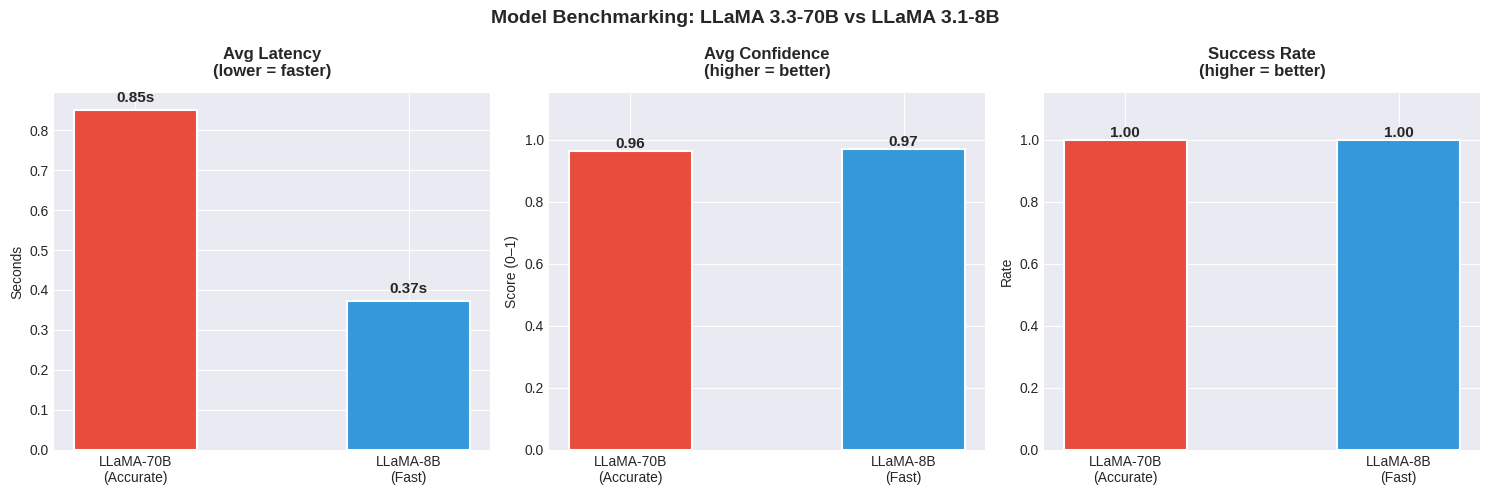


⚡ Benchmark chart saved as benchmark_results.png


In [12]:
bench_tickets = tickets[:5]
bench_results = {MODEL_MAIN: [], MODEL_FAST: []}

for model_name, model_id in [("LLaMA 3.3 70B", MODEL_MAIN), ("LLaMA 3.1 8B", MODEL_FAST)]:
    print(f"Benchmarking {model_name}...")
    for ticket in bench_tickets:
        r = triage_ticket(ticket, model=model_id)
        bench_results[model_id].append(r)
        time.sleep(0.3)
    print(f"  ✅ Done\n")

def get_metrics(res_list):
    ok = [r for r in res_list if r.get("status") == "success"]
    return {
        "success_rate"  : len(ok) / max(len(res_list), 1),
        "avg_latency"   : sum(r["latency_s"] for r in ok) / max(len(ok), 1),
        "avg_confidence": sum(r.get("confidence", 0) for r in ok) / max(len(ok), 1),
    }

metrics = {mid: get_metrics(res) for mid, res in bench_results.items()}

# ── Table ─────────────────────────────────────────────────────────────────────
print("═"*72)
print(f"  {'Model':<38} {'Success':>9} {'Avg Latency':>13} {'Avg Confidence':>15}")
print("═"*72)
labels = {"llama-3.3-70b-versatile": "LLaMA 3.3-70B (Versatile)",
          "llama-3.1-8b-instant"   : "LLaMA 3.1-8B  (Instant)"}
for mid, m in metrics.items():
    print(f"  {labels.get(mid, mid):<38} {m['success_rate']:>8.0%} "
          f"{m['avg_latency']:>12.2f}s {m['avg_confidence']:>14.2f}")
print("═"*72)

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Benchmarking: LLaMA 3.3-70B vs LLaMA 3.1-8B", fontsize=14, fontweight="bold")

model_labels = ["LLaMA-70B\n(Accurate)", "LLaMA-8B\n(Fast)"]
colors       = ["#e74c3c", "#3498db"]
metrics_list = [metrics[MODEL_MAIN], metrics[MODEL_FAST]]

for ax, key, title, ylabel, higher_is_better in zip(
    axes,
    ["avg_latency", "avg_confidence", "success_rate"],
    ["Avg Latency\n(lower = faster)", "Avg Confidence\n(higher = better)", "Success Rate\n(higher = better)"],
    ["Seconds", "Score (0–1)", "Rate"],
    [False, True, True],
):
    vals  = [m[key] for m in metrics_list]
    bars  = ax.bar(model_labels, vals, color=colors, edgecolor="white", linewidth=1.5, width=0.45)
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_ylabel(ylabel)
    if key != "avg_latency":
        ax.set_ylim(0, 1.15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + (0.01 if key != "avg_latency" else 0.02),
                f"{val:.2f}" + ("s" if key == "avg_latency" else ""),
                ha="center", fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("benchmark_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n⚡ Benchmark chart saved as benchmark_results.png")

---
## 📋 Step 10: Final Summary Report


In [13]:
print("╔═══════════════════════════════════════════════════════════════════╗")
print("║              🤖 ASSISTFLOW AI — FINAL SUMMARY REPORT              ║")
print("╚═══════════════════════════════════════════════════════════════════╝")

total   = len(df)
success = len([r for r in results if r.get("status") == "success"])

print(f"\n  📦 PROCESSING")
print(f"     Tickets Total          : {len(tickets)}")
print(f"     Successfully Triaged   : {success} ({success/len(tickets):.0%})")
print(f"     Avg Latency / Ticket   : {df['Latency(s)'].mean():.2f}s")
print(f"     Avg Confidence Score   : {df['Confidence'].mean():.2%}")

print(f"\n  🚨 URGENCY BREAKDOWN")
for level, color in zip(["CRITICAL","HIGH","MEDIUM","LOW"], ["🔴","🟠","🟡","🟢"]):
    cnt = (df["Urgency"] == level).sum()
    bar = "█" * cnt + "░" * (10 - cnt)
    print(f"     {color} {level:<10} [{bar}] {cnt} tickets")

print(f"\n  😤 SENTIMENT")
for sent in df["Sentiment"].value_counts().index:
    cnt = (df["Sentiment"] == sent).sum()
    print(f"     • {sent:<12} : {cnt} tickets")

print(f"\n  📂 TOP 5 CATEGORIES")
for cat, cnt in df["Category"].value_counts().head(5).items():
    print(f"     • {cat:<35}: {cnt}")

print(f"\n  🔬 A/B PROMPT TEST")
print(f"     Prompt A avg confidence: {avg_a:.2f}")
print(f"     Prompt B avg confidence: {avg_b:.2f}")
print(f"     Winner: Prompt {'B (Detailed)' if avg_b >= avg_a else 'A (Minimal)'}")

print(f"\n  🚨 DRIFT DETECTION")
print(f"     Status : {drift['status'].upper()}")
if drift["alerts"]:
    for a in drift["alerts"]:
        print(f"     ⚠️  {a['category']} → {a['recent']} of recent tickets (Δ {a['delta']})")
else:
    print("     ✅ No drift detected")

print(f"\n  ⚡ MODEL BENCHMARK")
for mid, m in metrics.items():
    nm = "LLaMA-70B" if "70b" in mid else "LLaMA-8B "
    print(f"     {nm} | Latency: {m['avg_latency']:.2f}s | Confidence: {m['avg_confidence']:.2f}")

print(f"\n  💰 PROJECTED BUSINESS IMPACT")
print(f"     Resolution Time  : 48h → 24h  (AI-assisted triage)")
print(f"     FCR Target       : 60% → 80%  (better routing accuracy)")
print(f"     CSAT Target      : 3.8 → 4.2  (faster, smarter responses)")
print(f"     Cost Savings     : ~$800K/year (reduced misrouting overhead)")

print("\n" + "═"*70)
print("  Built with: Python  ·  Groq API  ·  LLaMA 3  ·  Pandas  ·  Matplotlib")
print("═"*70)

╔═══════════════════════════════════════════════════════════════════╗
║              🤖 ASSISTFLOW AI — FINAL SUMMARY REPORT              ║
╚═══════════════════════════════════════════════════════════════════╝

  📦 PROCESSING
     Tickets Total          : 20
     Successfully Triaged   : 20 (100%)
     Avg Latency / Ticket   : 0.84s
     Avg Confidence Score   : 90.35%

  🚨 URGENCY BREAKDOWN
     🔴 CRITICAL   [█████░░░░░] 5 tickets
     🟠 HIGH       [██████░░░░] 6 tickets
     🟡 MEDIUM     [████░░░░░░] 4 tickets
     🟢 LOW        [█████░░░░░] 5 tickets

  😤 SENTIMENT
     • frustrated   : 10 tickets
     • neutral      : 9 tickets
     • angry        : 1 tickets

  📂 TOP 5 CATEGORIES
     • feature_request                    : 6
     • access_authentication              : 3
     • performance                        : 3
     • data_integrity                     : 2
     • api_integration                    : 2

  🔬 A/B PROMPT TEST
     Prompt A avg confidence: 0.92
     Prompt B avg conf